# LambdaLLG 1D Spin-Transfer-Torque Domain Wall Test

This notebook is a simple field-free sanity check for the new 1D spin-transfer torque.
We first relax a Bloch wall in zero applied field, then compare a zero-current control against a current-driven run with `evolve1D(...; stt=true)`.

The phenomenological torque implemented here is the standard Zhang-Li form used in current-driven domain-wall literature,

`tau_stt = -u_stt * d_x m + beta_stt * u_stt * (m x d_x m)`, evaluated in lattice units with spacing `a = 1`.


In [1]:
using Pkg; Pkg.activate("../")


  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
using LambdaLLG
using LinearAlgebra
using Statistics
import PyPlot as plt


[ Info: Precompiling LambdaLLG [e49eaffb-1ff4-4058-b8bd-8b5ecf266929] (cache misses: include_dependency fsize change (2), mismatched flags (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Helpers

The wall center is taken as the site where `m_z` is closest to zero.


In [3]:
function normalize_column!(v)
    n = sqrt(sum(abs2, v))
    v ./= n
    return v
end

function bloch_wall(Nx, x0, Delta; chirality=1.0)
    s0 = zeros(3, Nx)
    for i in 1:Nx
        xi = (i - x0) / Delta
        mz = tanh(xi)
        my = chirality / cosh(xi)
        s0[:, i] .= (0.0, my, mz)
        normalize_column!(view(s0, :, i))
    end
    return s0
end

wall_center(mz) = argmin(abs.(mz))

function wall_centers(sol, Nx)
    return [wall_center(reshape(u, 3, Nx)[3, :]) for u in sol.u]
end


wall_centers (generic function with 1 method)

## Model Parameters

These values give a clear qualitative demonstration of current-driven motion while keeping the wall profile close to the relaxed Bloch texture.


In [4]:
Nx = 121
x0 = (Nx + 1) / 2
Delta = 6.0
sites = 1:Nx

J = 1.0
K = (0.0, 0.0, 0.35)
alpha = 0.25
D_bulk = (0.25, 0.0, 0.0)

u_stt = 0.2
beta_stt = 0.3

t_relax = (0.0, 80.0)
t_drive = (0.0, 120.0)


(0.0, 120.0)

## 1. Relax a zero-field Bloch wall

The relaxed wall will be used as the common initial condition for both the control and current-driven runs.


In [5]:
s0 = bloch_wall(Nx, x0, Delta)

p_eq = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=D_bulk)
sol_eq = evolve1D(copy(s0), t_relax, p_eq; reltol=1e-6, abstol=1e-6)

s_eq = reshape(sol_eq.u[end], 3, Nx)
center_eq = wall_center(s_eq[3, :])

display((center_eq=center_eq, center_spin=s_eq[:, center_eq]))


(center_eq = 61, center_spin = [0.0, 1.0, 0.0])

## 2. Compare a control run and an STT-driven run

Both runs use zero applied magnetic field. The only difference is that the second call enables STT with `stt=true` and nonzero `u_stt`, `beta_stt`. The discrete derivative is taken with lattice spacing `a = 1`.


In [6]:
p_control = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=D_bulk)
sol_control = evolve1D(copy(s_eq), t_drive, p_control; reltol=1e-6, abstol=1e-6)
s_control_final = reshape(sol_control.u[end], 3, Nx)
centers_control = wall_centers(sol_control, Nx)
center_control = wall_center(s_control_final[3, :])

p_drive = LLGParams1D(
    Nx,
    J,
    K,
    (0.0, 0.0, 0.0),
    alpha;
    D=D_bulk,
    u_stt=u_stt,
    beta_stt=beta_stt,
)
sol_drive = evolve1D(copy(s_eq), t_drive, p_drive; reltol=1e-6, abstol=1e-6, stt=true)
s_drive_final = reshape(sol_drive.u[end], 3, Nx)
centers_drive = wall_centers(sol_drive, Nx)
center_drive = wall_center(s_drive_final[3, :])

display((
    center_relaxed=center_eq,
    center_control=center_control,
    center_drive=center_drive,
    control_shift=center_control - center_eq,
    drive_shift=center_drive - center_eq,
    mean_abs_mx=mean(abs.(s_drive_final[1, :])),
    mean_abs_my=mean(abs.(s_drive_final[2, :])),
))


(center_relaxed = 61, center_control = 61, center_drive = 88, control_shift = 0, drive_shift = 27, mean_abs_mx = 0.008624309368840677, mean_abs_my = 0.05527129269034176)

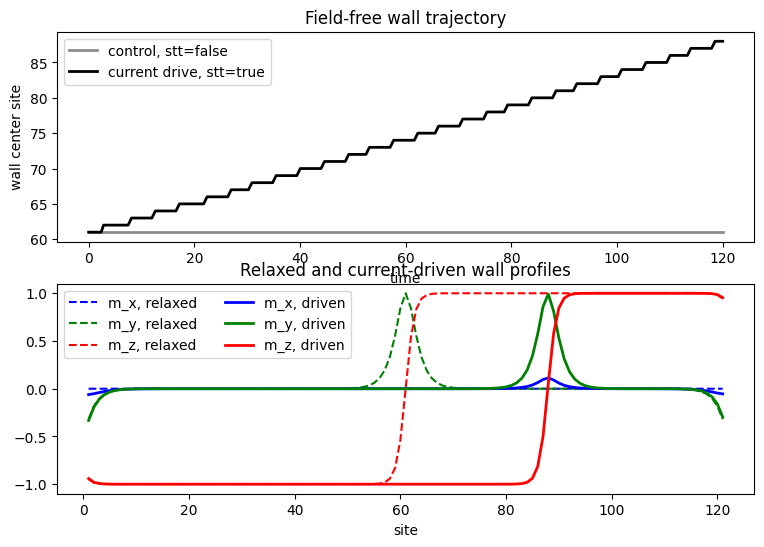

PyObject <matplotlib.legend.Legend object at 0x000001A85FF1A790>

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=false)

ax[1].plot(sol_control.t, centers_control, color="0.55", lw=2, label="control, stt=false")
ax[1].plot(sol_drive.t, centers_drive, color="k", lw=2, label="current drive, stt=true")
ax[1].set_xlabel("time")
ax[1].set_ylabel("wall center site")
ax[1].set_title("Field-free wall trajectory")
ax[1].legend(loc="best")

ax[2].plot(sites, s_control_final[1, :], "b--", lw=1.5, label="m_x, relaxed")
ax[2].plot(sites, s_control_final[2, :], "g--", lw=1.5, label="m_y, relaxed")
ax[2].plot(sites, s_control_final[3, :], "r--", lw=1.5, label="m_z, relaxed")
ax[2].plot(sites, s_drive_final[1, :], "b", lw=2, label="m_x, driven")
ax[2].plot(sites, s_drive_final[2, :], "g", lw=2, label="m_y, driven")
ax[2].plot(sites, s_drive_final[3, :], "r", lw=2, label="m_z, driven")
ax[2].set_xlabel("site")
ax[2].set_title("Relaxed and current-driven wall profiles")
ax[2].legend(loc="best", ncol=2)


## Notes

- For the parameters above, the control stays pinned while the STT-driven wall shifts by about 27 lattice sites with zero applied field.
- `stt=true` is required in `evolve1D`; leaving it at the default `false` suppresses STT even if `u_stt` and `beta_stt` are set in `LLGParams1D`.
- The STT derivative is evaluated in lattice units, so this example assumes lattice spacing `a = 1`.
- Flipping the sign of `u_stt` reverses the direction of motion.
